In [70]:
from glider import IGCFile
from glider import GoProVideoMetadata, GoProGPX
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import cv2
import datetime
from zoneinfo import ZoneInfo

igc = IGCFile("2026-05-01-XTR-A68A17562166-01.IGC")
meta0 = GoProVideoMetadata.from_video("GX020107.MP4")
meta1 = GoProVideoMetadata.from_video("GX020107.MP4")

img = Image.open("frame.jpg")
frame = np.array(img)

In [71]:
gpx = GoProGPX("GX020107.MP4")

In [81]:
data = [{"date": x.time, "lat": x.latitude, "lon": x.longitude} for x in gpx.track]

In [ ]:
import pandas as pd
df = pd.DataFrame(data)

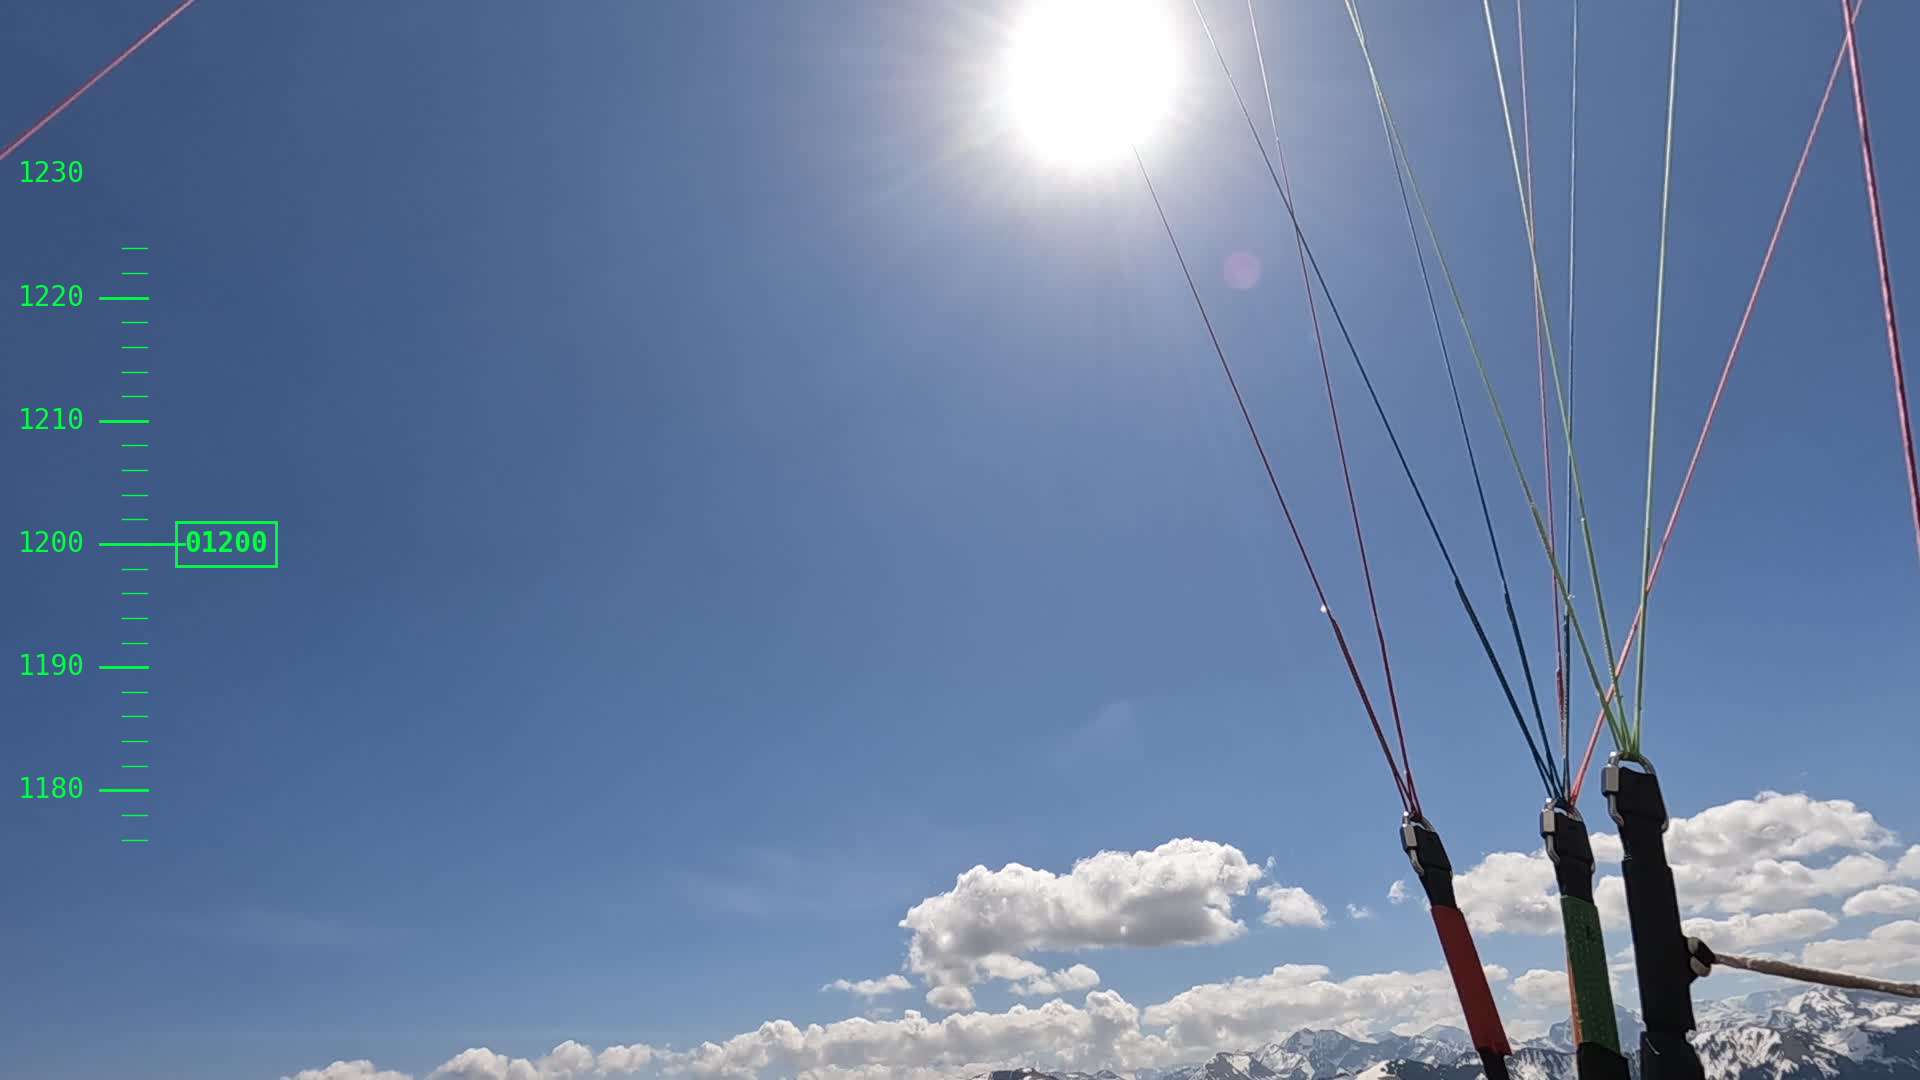

In [65]:
def draw_hud_with_box(current_alt, frame):
    hud_green = '#00FF41'
    top_bot = 25
    major_ticks = 10
    minor_thicks = 2
    fig, ax = plt.subplots(figsize=(4, 8))
    # ax.set_facecolor('black')
    
    # HUD Tape Line (Right Spine)
    # for spine in ['top', 'bottom', 'left']:
    #     ax.spines[spine].set_visible(False)
    # ax.spines['right'].set_color(hud_green)
    # ax.spines['right'].set_linewidth(2)
    ax.spines.clear()

    # Set view range (e.g., show 300 units above/below current)
    ax.set_ylim(current_alt - top_bot, current_alt + top_bot)

    # Draw ticks and labels
    start_tick = int((current_alt - top_bot) // minor_thicks * minor_thicks)
    for val in range(start_tick, int(current_alt + top_bot * 1.25), minor_thicks):
        is_major = val % major_ticks == 0
        tick_len = 0.15 if is_major else 0.08
        
        # Draw tick lines (at x=0.7 to leave room for the box on the right)
        ax.plot([0.7 - tick_len, 0.7], [val, val], color=hud_green, 
                lw=2 if is_major else 1, transform=ax.get_yaxis_transform())
        
        if is_major:
            ax.text(0.5, val, f"{val:04d}", color=hud_green, fontsize=20, 
                    ha='right', va='center', family='monospace', transform=ax.get_yaxis_transform())

    # THE BOX: Current Altitude Readout
    box_style = dict(boxstyle='square,pad=0.3', facecolor='none', edgecolor=hud_green, linewidth=2)
    ax.text(0.82, current_alt, f"{current_alt:05d}", color=hud_green, fontsize=20,
            ha='left', va='center', family='monospace', fontweight='bold',
            bbox=box_style, transform=ax.get_yaxis_transform())
    
    # Connecting line from tape to box
    ax.plot([0.7, 0.82], [current_alt, current_alt], color=hud_green, lw=2, transform=ax.get_yaxis_transform())

    ax.set_xticks([])
    ax.set_yticks([])
    # plt.savefig(output_path, facecolor='black', bbox_inches='tight')
    import io
    buf = io.BytesIO()
    fig.savefig(buf, format='png', transparent=True)
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf).convert("RGBA")
    img = img.crop([120, 0, img.size[0], img.size[1]])
    bg = Image.fromarray(frame)
    pos_y = round(bg.size[1] / 2 - img.size[1] / 2)
    bg.paste(img, ( 0, pos_y), img)
    return np.array(bg)

img = draw_hud_with_box(1200, frame)
Image.fromarray(img)


Filtered: [np.float64(1708.502172563625), np.float64(1723.2230545556351), np.float64(1729.2723198445724), np.float64(1732.6957568615305), np.float64(1734.662976188741), np.float64(1736.0343350887783), np.float64(1736.7259850624787), np.float64(1737.0993006367246), np.float64(1737.0694476830668), np.float64(1736.6173476533202), np.float64(1735.9471819701519), np.float64(1735.1224570740183), np.float64(1734.1275060349717), np.float64(1733.1419836909554), np.float64(1732.0338968755375), np.float64(1731.087225922834), np.float64(1730.2511801823207), np.float64(1729.5339546818761), np.float64(1728.8170070365409), np.float64(1728.0369518608472), np.float64(1727.3657426849172), np.float64(1726.6497660526845), np.float64(1726.0331162759478), np.float64(1725.3513725418736), np.float64(1724.7764376959026), np.float64(1724.2809251953781), np.float64(1723.8412824511454), np.float64(1723.6126148877), np.float64(1723.2651757412937), np.float64(1722.8403905989878), np.float64(1722.474151256101), np.f

np.float64(1814.968618159549)

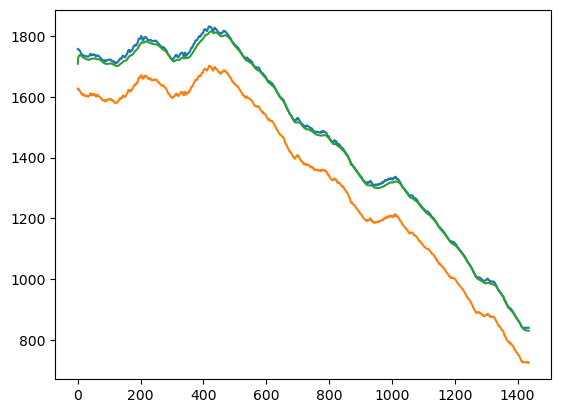

In [61]:

## Python Implementation

class AltitudeFusionKF:
    def __init__(self, dt=1):
        # State: [Altitude, Pressure_Bias]
        self.x = np.array([[0.0], [0.0]]) 
        self.P = np.eye(2) * 10.0
        
        # State Transition (Altitude = Altitude_old + Bias_old * 0)
        self.F = np.array([[1.0, 0.0],
                           [0.0, 1.0]])
        
        # Process Noise (Trust altitude to move, bias to stay stable)
        self.Q = np.array([[0.0001, 0.0], 
                           [0.0, 0.1]]) 
        
        # Measurement Matrices
        self.H_gps = np.array([[1.0, 1.0]])    # GPS measures altitude
        self.H_press = np.array([[0.0, 1.0]])  # Press measures altitude + bias
        
        # Measurement Noise
        self.R_gps = np.array([[0.5]])   # GPS is noisy
        self.R_press = np.array([[5.0]]) # Pressure is precise (relatively)

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update_gps(self, z_gps):
        z = np.array([[z_gps]])
        y = z - (self.H_gps @ self.x)
        S = self.H_gps @ self.P @ self.H_gps.T + self.R_gps
        K = self.P @ self.H_gps.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(2) - K @ self.H_gps) @ self.P

    def update_press(self, z_press):
        z = np.array([[z_press]])
        y = z - (self.H_press @ self.x)
        S = self.H_press @ self.P @ self.H_press.T + self.R_press
        K = self.P @ self.H_press.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(2) - K @ self.H_press) @ self.P

    def get_altitude(self):
        return self.x[0, 0]

## How to use it

#    1. Call predict() at every time step (e.g., 10Hz or 50Hz).
#    2. Call update_press() whenever you get a pressure reading (fast).
#    3. Call update_gps() only when the GPS provides a new coordinate (slow).

# This structure ensures that even when the pressure sensor starts to drift by 10 meters, the GPS update will pull the Pressure_Bias state in the opposite direction, effectively "zeroing out" the sensor error in real-time.
# Should I explain how to add vertical velocity (climb rate) to this state for even smoother tracking?

def simple_altitude_kalman(gps_alt, pressure_alt, dt=1.0):
    # State: [Altitude]
    # Prediction: x = x (constant altitude model for simplicity)
    # Process noise (Q): How much we trust the model/how much altitude can change
    # Measurement noise (R): GPS (slow, stable) vs Pressure (fast, drift-prone)
    
    x = pressure_alt[0] # Initial state
    P = 1.0 # Initial uncertainty
    
    Q = 0.01 # Process noise
    R_gps = 0.5 # GPS measurement noise (less trust in individual samples)
    R_press = 5 # Pressure measurement noise (high trust in relative change)
    
    estimates = []
    
    for g, p in zip(gps_alt, pressure_alt):
        # 1. Predict
        x = x 
        P = P + Q
        
        # 2. Update with Pressure (Fast, frequent)
        K_p = P / (P + R_press)
        x = x + K_p * (p - x)
        P = (1 - K_p) * P
        
        # 3. Update with GPS (Corrects the drift)
        K_g = P / (P + R_gps)
        x = x + K_g * (g - x)
        P = (1 - K_g) * P
        
        estimates.append(x)
    return estimates

# Example 
# 
gps_data = [100, 101, 102, 103, 104]
press_data = [102, 105, 108, 110, 112] # Drifting away
# 
filtered = simple_altitude_kalman(igc.altitude_df['alt_gps'], igc.altitude_df['alt_pressure'])
print(f"Filtered: {filtered}")

plt.plot(igc.altitude_df['alt_gps'])
plt.plot(igc.altitude_df['alt_pressure'])
plt.plot(filtered)
max(filtered)

In [50]:

def draw_fa18_high_res_compass(heading, frame):
    hud_green = '#00FF41'
    current_hdg = heading % 360
    
    fig, ax = plt.subplots(figsize=(10, 4), facecolor='black')
    # ax.set_facecolor('black')
    
    radius, center_y, view_span = 10.0, -9.2, 20  # span reduced slightly for clarity
    
    # Draw curved rail
    arc_ans = np.linspace(np.radians(90 - view_span), np.radians(90 + view_span), 100)
    ax.plot(radius * np.cos(arc_ans), radius * np.sin(arc_ans) + center_y, color=hud_green, lw=2)

    # 1-degree resolution loop
    search_min = int(np.floor(current_hdg - view_span))
    search_max = int(np.ceil(current_hdg + view_span))

    for h in range(search_min, search_max + 1):
        offset = h - current_hdg
        
        if abs(offset) <= view_span:
            angle_rad = np.radians(90 - offset)
            display_deg = h % 360
            
            # Determine tick style
            if display_deg % 10 == 0:
                r_in = 9.7  # Long
                lw = 2
            elif display_deg % 5 == 0:
                r_in = 9.82 # Medium
                lw = 1.5
            else:
                r_in = 9.92 # Short (1-degree resolution)
                lw = 0.8
                
            # Plot tick
            ax.plot([r_in * np.cos(angle_rad), radius * np.cos(angle_rad)],
                    [r_in * np.sin(angle_rad) + center_y, radius * np.sin(angle_rad) + center_y],
                    color=hud_green, lw=lw)
            
            # Labels for 10-degree increments
            if display_deg % 10 == 0:
                label = {0:'N', 90:'E', 180:'S', 270:'W'}.get(display_deg, f"{int(display_deg/10):02d}")
                tx, ty = 9.3 * np.cos(angle_rad), 9.3 * np.sin(angle_rad) + center_y
                ax.text(tx, ty, label, color=hud_green, fontsize=20, 
                        ha='center', va='center', family='monospace', fontweight='bold')

    # HUD center-markers
    ax.text(0, 0.9, '∨', color=hud_green, fontsize=24, ha='center', fontweight='bold')
    ax.text(0, 1.25, f"{int(current_hdg):03d}", color=hud_green, fontsize=18, 
            ha='center', family='monospace', fontweight='bold',
            bbox=dict(boxstyle='square,pad=0.2', fc='none', ec=hud_green, lw=2))

    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-0.5, 1.8)
    ax.set_aspect('equal')
    ax.axis('off')

    import io
    buf = io.BytesIO()
    fig.savefig(buf, format='png', transparent=True)
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf).convert("RGBA")
    img = img.crop([0, 100, 1000, 400])
    bg = Image.fromarray(frame)
    pos_x = round(bg.size[0] / 2 - img.size[0] / 2)
    bg.paste(img, (pos_x, 0), img)
    return np.array(bg)

frm = draw_fa18_high_res_compass(123, frame)

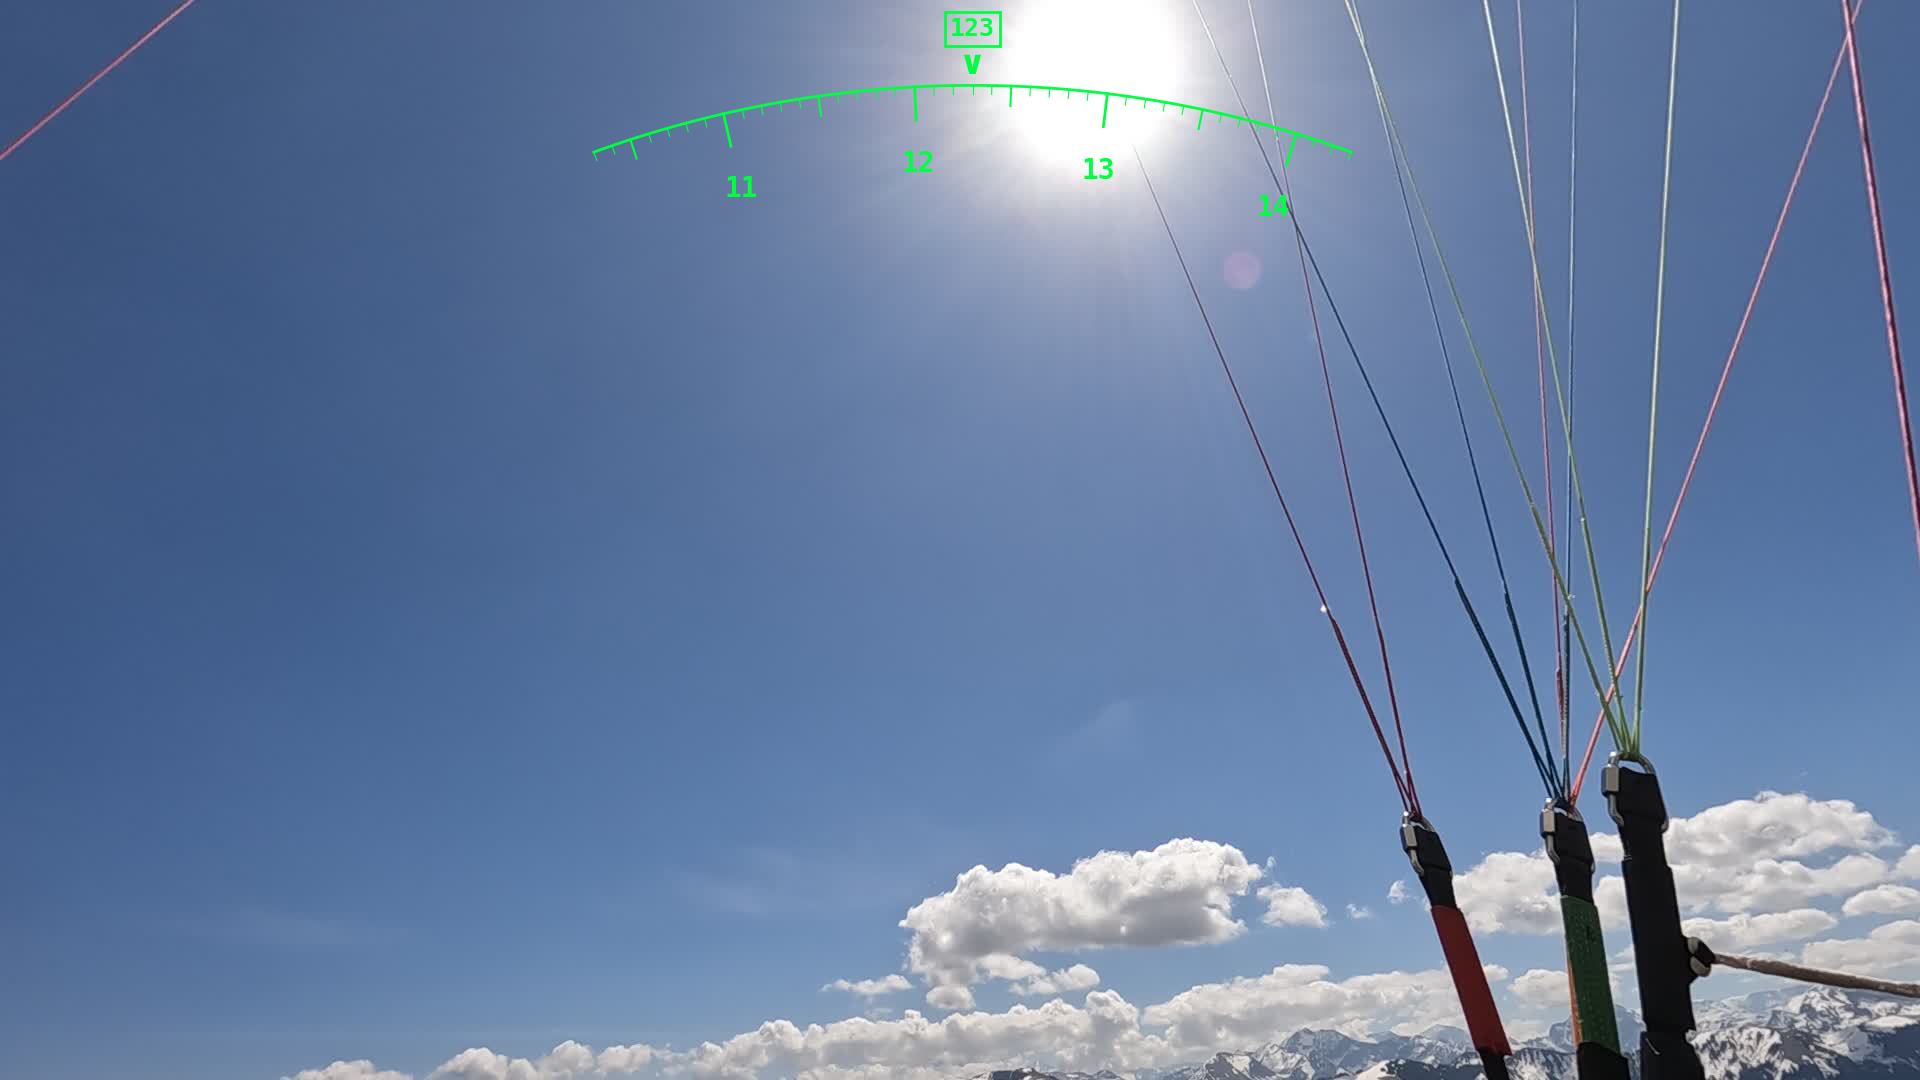

In [88]:
Image.fromarray(frm)

(1920, 1080)

In [51]:
frame.shape

(1080, 1920, 3)

In [ ]:


compass_position = (10,10)
compass_background = Image.open("compass_background.png").convert("RGBA").resize((200, 200), Image.Resampling.LANCZOS)
needle = Image.open("compass_needle.png").convert("RGBA").resize((200, 200), Image.Resampling.LANCZOS)
needle_center = [x/2 for x in needle.size]

def draw_compass(frame: np.array, heading: float):
    img = Image.fromarray(frame)
    rotated_overlay = needle.rotate(-heading, center=needle_center, resample=Image.BICUBIC)
    img.paste(compass_background, compass_position, compass_background)
    img.paste(rotated_overlay, compass_position, rotated_overlay)
    frame = np.array(img)
    return frame



In [ ]:

nowutc = datetime.datetime.now(tz=datetime.UTC)

In [ ]:
import re
import os
pattern = r"G[XH](\d{2})(\d{4})"
for f in os.listdir("."):
    match = re.search(pattern, f)
    if match:
        chapter_zz = match.group(1)
        file_id_xxxx = match.group(2)
        print(f"File: {f} -> Chapter: {chapter_zz}, ID: {file_id_xxxx}")

In [ ]:
import datetime
backwards, forwards = igc.get_altitude_progression(time)

In [ ]:
def draw_altitude_line(igc: IGCFile, time: datetime, frame):
    backwards, forwards = igc.get_altitude_progression(time)
    y = [*-backwards, *-forwards]
    y = y + min(y)
    x = [x for x in range(len(y))]
    x_image_size = 280
    y_image_size = 100
    plot_position = (240, 90)
    x_scaled = plot_position[0] + (x - np.min(x)) / (np.max(x) - np.min(x)) * x_image_size
    y_scaled = plot_position[1] + (y - np.min(y)) / (np.max(y) - np.min(y)) * y_image_size

    x = x_scaled
    y = y_scaled

    points = np.column_stack((x, y)).astype(np.int32)

    # 3. Draw the Fading Shadow (Negative Y direction)
    # In image coordinates, "down" is the positive Y-axis.
    shadow_layers = 25
    max_alpha = 0.2

    for i in range(shadow_layers, 0, -1):
        # Create a transparent overlay for the current shadow layer
        overlay = frame.copy()
        
        # Calculate transparency: fades out as it moves away from the line
        alpha = max_alpha * (1 - i / shadow_layers)**1.5
        
        # Offset the points downward to create the shadow effect
        offset_points = points.copy()
        offset_points[:, 1] += i
        
        # Draw the shadow line on the overlay
        cv2.polylines(overlay, [offset_points], isClosed=False, color=(75, 150, 200), thickness=5)
        
        # Blend the overlay back into the main image
        frame = cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0)

    # 4. Draw the main curve on top
    cv2.polylines(frame, [points[0:int(len(backwards))]], isClosed=False, color=(0, 0, 0), thickness=4, lineType=cv2.LINE_AA)
    cv2.polylines(frame, [points[int(len(backwards)):]], isClosed=False, color=(0, 255, 0), thickness=4, lineType=cv2.LINE_AA)
    return frame

In [ ]:
sample_time = datetime.datetime(year=2026, month=5, day=1, hour=10, minute=2, second=0, tzinfo=datetime.UTC)
backwards, forwards = igc.get_altitude_progression(sample_time)
alt = igc.get_gps_altitude_at_time(sample_time)
forwards[0],alt

In [ ]:
[*-backwards,*-forwards]

In [ ]:


timestring = sample_time.replace(microsecond=0).astimezone(ZoneInfo("Europe/Zurich")).isoformat()

frame = cv2.putText(
    frame,
    timestring,
    (25, frame.shape[0]-25), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 3)
frame = cv2.putText(
    frame,
    "ALT 1234 m",
    (240, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3)
frame = draw_compass(frame, 90)
frame = draw_altitude_line(igc, sample_time, frame)

Image.fromarray(frame)

In [ ]:
import pandas as pd
import numpy as np

bearing_df = pd.DataFrame([
    {"ts": x.gpx_track_point.time.timestamp(), 
     "b_x": np.cos(x.bearing.bearing_rad),
     "b_y": np.sin(x.bearing.bearing_rad)} for x in igc.records
])

In [ ]:
igc.records[4].bearing

In [ ]:
import datetime
igc.get_altitude_at_time(datetime.datetime.fromtimestamp(1777629.0))

In [ ]:
igc.bearing_df['ts'].iloc[760]
